# 08 — Prostorová segregace singuláru a plurálu

Otázka: **leží obce se stejným gramatickým číslem (plurál/singulár) blíž sobě
navzájem, než by odpovídalo náhodnému rozmístění týchž labelů na týchž
souřadnicích?**

Tohle není clustering v ML smyslu (k-means na souřadnicích) — labely už máme
dané, testujeme jejich **prostorovou autokorelaci/segregaci** na fixních
bodech. V geoinformatice a prostorové epidemiologii se na tuto otázku
odpovídá dvěma standardními, komplementárními nástroji:

1. **Join-count statistika** (Cliff & Ord) — na k-nejbližších-sousedech grafu
   spočítá, kolik sousedících dvojic obcí má stejný label (PL–PL, SG–SG) vs.
   různý (PL–SG), a porovná s rozdělením pod **náhodnou permutací labelů na
   týchž souřadnicích** ("random labeling" null model).
2. **Globální Moran's I** na binární proměnné (1=plurál, 0=singulár) —
   obecně známější ukazatel prostorové autokorelace, stejná permutační logika.
3. **LISA** (Local Indicators of Spatial Association) — doplněk: globální
   test řekne "shlukuje se to", LISA řekne **kde**.

Inference je všude **permutační (Monte Carlo)**, ne klasické asymptotické
p-value — prostorová data nejsou i.i.d. (Toblerův zákon: blízké věci si jsou
podobnější), takže klasický chí-kvadrát na náhodných dvojicích by byl
anti-konzervativní. Permutační test naopak přesně odpovídá na otázku "je
pozorované prostorové uspořádání překvapivé vzhledem k tomu, že tahle
konkrétní sada labelů je rozmístěná na těchto konkrétních 1 643 bodech?"

Implementace: `libpysal`/`esda` (standardní PySAL toolkit), funkce
`build_knn_weights`, `join_count_test`, `moran_binary_test`,
`moran_local_test`, `plot_moran_scatter`, `plot_lisa_map` v `src/geogram/viz.py`.

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np

from geogram import viz, config

viz.set_style()

DATA = config.PROCESSED_DIR
WIKI_CSV = DATA / "ice_grammar_wiki_v2.csv"
COORDS_CSV = DATA / "municipalities_ice_integrated.csv"


## 1. Příprava dat

`ice_grammar_wiki_v2.csv` (výstup nb07) nemá souřadnice, `municipalities_ice_integrated.csv`
(výstup nb04) je má — spojujeme přes `code` (RÚIAN kód obce).

In [2]:
wiki = pd.read_csv(WIKI_CSV)
coords = pd.read_csv(COORDS_CSV)[["code", "latitude", "longitude"]]
df = wiki.merge(coords, on="code", how="left")

print(f"Celkem: {len(df)} obcí, chybí souřadnice: {df['latitude'].isna().sum()}")

# Testujeme jen jednoznačně klasifikované obce (singular/plural) — unknown
# a not_found nemají definovaný label, "both" (pomnožné i v singuláru) je
# jen 3 obce, vyloučeny stejně jako v chi2 testech v nb07.
d = df[df["wiki_number"].isin(["singular", "plural"])]
print(d["wiki_number"].value_counts())

Celkem: 1806 obcí, chybí souřadnice: 0
wiki_number
plural      1410
singular     233
Name: count, dtype: int64


## 2. Prostorová váhová matice (k-NN)

Volíme **k = 6 nejbližších sousedů** — běžný výchozí kompromis v prostorové
statistice (dost sousedů na stabilní odhad lokální struktury, dost málo na
to, aby "sousedství" zůstalo lokální). Souřadnice se před výpočtem vzdáleností
projikují do S-JTSK/Krovák (EPSG:5514, metrické), ne počítají v stupních
lat/lon — `build_knn_weights()` to dělá automaticky. Robustnost volby k
ověřujeme v sekci 5.

In [3]:
gdf, w = viz.build_knn_weights(d, k=6)
print(f"n = {len(gdf)} obcí, k = 6 sousedů/obec, {w.n * 6} hran v grafu")

n = 1643 obcí, k = 6 sousedů/obec, 9858 hran v grafu


## 3. Join-count test

`bb` = počet sousedících dvojic plurál–plurál, `ww` = singulár–singulár,
`bw` = smíšené dvojice. Pokud jsou labely prostorově shlukované, čekáme
**bb_obs > bb_exp** (a symetricky **bw_obs < bw_exp**) — víc "svých" sousedů,
míň smíšených hranic, než náhoda čeká.

In [4]:
jc = viz.join_count_test(df, k=6, permutations=9999, seed=42)

print(f"n = {jc['n']} obcí ({jc['n_plural']} plurál, {jc['n_singular']} singulár), k = {jc['k']}")
print(f"permutace: {jc['permutations']}")
print()
print(f"BB (plurál-plurál sousedé): pozorováno {jc['bb_obs']:.0f}, očekáváno {jc['bb_exp']:.1f}, p_sim = {jc['p_sim_bb']:.4f}")
print(f"BW (smíšené dvojice):       pozorováno {jc['bw_obs']:.0f}, očekáváno {jc['bw_exp']:.1f}, p_sim = {jc['p_sim_bw']:.4f}")
print(f"WW (singulár-singulár):     pozorováno {jc['ww_obs']:.0f}")
print()
print(f"chi2 = {jc['chi2']:.2f}, chi2_p = {jc['chi2_p']:.2e} (doplňkový klasický test, orientační)")

n = 1643 obcí (1410 plurál, 233 singulár), k = 6
permutace: 9999

BB (plurál-plurál sousedé): pozorováno 3747, očekáváno 3629.5, p_sim = 0.0001
BW (smíšené dvojice):       pozorováno 1016, očekáváno 1200.8, p_sim = 1.0000
WW (singulár-singulár):     pozorováno 166

chi2 = 79.56, chi2_p = 4.68e-19 (doplňkový klasický test, orientační)


**Interpretace:** `p_sim_bb` blízko 0 znamená, že v žádné (nebo skoro žádné)
z 9 999 náhodných permutací labelů na týchž souřadnicích nevyšel počet
plurál-plurál sousedství tak vysoký jako pozorovaný — plurálové obce leží u
sebe systematicky víc, než náhoda vysvětlí. `p_sim_bw` blízko 1 říká totéž
z druhé strany: smíšených (plurál vedle singuláru) hranic je pozorovaně
**méně**, než náhoda čeká.

## 4. Moran's I (doplňkový test)

Obecně známější ukazatel prostorové autokorelace — stejná permutační
inference, jiná matematická formulace (kovariance vs. počítání sousedství).
Slouží jako robustnost check na join-count výsledek.

Moran's I = 0.1240 (očekávané pod H0: -0.0006)
z_sim = 9.44, p_sim = 0.0001 (9999 permutací)


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/08_moran_scatter.png')

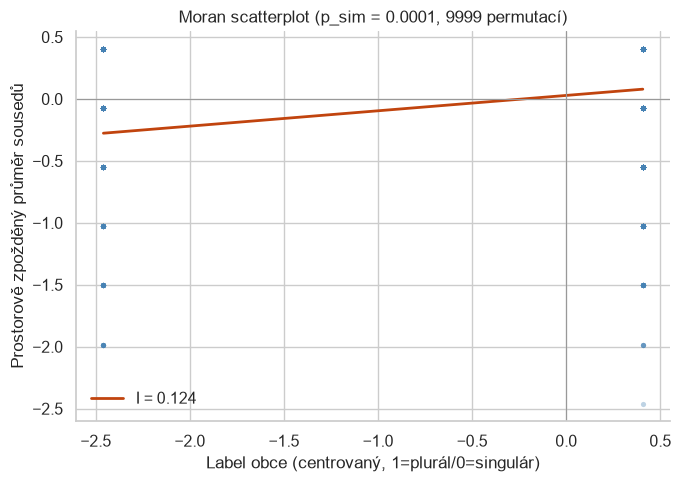

In [5]:
mi = viz.moran_binary_test(df, k=6, permutations=9999, seed=42)
print(f"Moran's I = {mi['I']:.4f} (očekávané pod H0: {mi['EI']:.4f})")
print(f"z_sim = {mi['z_sim']:.2f}, p_sim = {mi['p_sim']:.4f} ({mi['permutations']} permutací)")

fig = viz.plot_moran_scatter(mi["result"])
viz.save_fig(fig, "08_moran_scatter")

## 5. Citlivost na volbu k (robustnost)

Výsledek by neměl záviset na tom, jestli sousedství definujeme jako 4, 6, 10
nebo 15 nejbližších obcí — pokud efekt existuje, měl by být stabilní napříč
rozumnými volbami k.

In [6]:
rows = []
for k in [4, 6, 8, 10, 15, 20]:
    jc_k = viz.join_count_test(df, k=k, permutations=999, seed=42)
    mi_k = viz.moran_binary_test(df, k=k, permutations=999, seed=42)
    rows.append({
        "k": k,
        "join_count_p_sim_bb": jc_k["p_sim_bb"],
        "moran_I": round(mi_k["I"], 4),
        "moran_p_sim": mi_k["p_sim"],
    })

sensitivity = pd.DataFrame(rows)
sensitivity

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\libpysal\weights\distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\libpysal\weights\distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


,k,join_count_p_sim_bb,moran_I,moran_p_sim
0,4,0.001,0.1330,0.001
1,6,0.001,0.1240,0.001
2,8,0.001,0.1124,0.001
3,10,0.001,0.1016,0.001
4,15,0.001,0.0883,0.001
5,20,0.001,0.0788,0.001


## 6. LISA — kde přesně se shlukuje

Globální testy (3–5) odpověděly *ano, shlukuje se to*. LISA ukáže *kde* —
klasifikuje každou obec do jednoho ze 4 kvadrantů dle vlastního labelu a
labelu sousedů:

- **HH** (plurál obklopený plurálem) a **LL** (singulár obklopený singulárem)
  jsou "typické" lokální shluky.
- **HL/LH** jsou prostorové anomálie — obec jiného labelu, než mají její
  sousedé.

Významných (p < 0.05) LISA bodů: 351 / 1643 (21.4%)
lisa_q
HL    230
LH     72
LL     49
Name: count, dtype: int64


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/08_lisa_map.png')

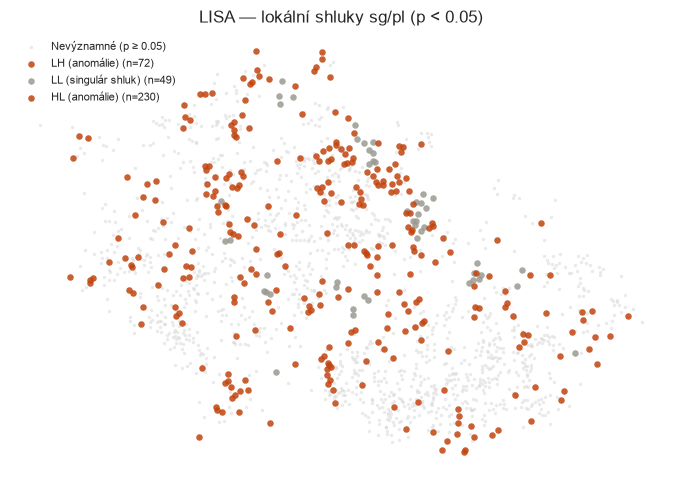

In [7]:
gdf_lisa, ml = viz.moran_local_test(df, k=6, permutations=999, seed=42)

n_sig = (gdf_lisa["lisa_p"] < 0.05).sum()
print(f"Významných (p < 0.05) LISA bodů: {n_sig} / {len(gdf_lisa)} ({n_sig/len(gdf_lisa):.1%})")
print(gdf_lisa.loc[gdf_lisa['lisa_p'] < 0.05, 'lisa_q'].map({1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}).value_counts())

fig = viz.plot_lisa_map(gdf_lisa)
viz.save_fig(fig, "08_lisa_map")

## 7. Shrnutí

**Globální testy shodně a silně signalizují prostorové shlukování:**
- Join-count: BB (plurál-plurál sousedství) pozorováno 3747 vs. očekáváno 3629.5 pod
  náhodným rozmístěním, p_sim = 0.0001 (0/9999 permutací dosáhlo tak vysoké hodnoty).
  BW (smíšené hranice) naopak méně časté, než náhoda čeká (p_sim = 1.0000 — nikdy nebylo
  smíšených hranic tak málo v žádné permutaci).
- Moran's I = 0.124 (očekáváno pod H0: ≈ 0), p_sim = 0.0001 — nezávislé potvrzení
  jinou matematickou formulací.
- Robustnost (sekce 5): efekt je stabilní napříč k = 4–20, p_sim zůstává < 0.01 pro
  všechny volby — není to artefakt jedné konkrétní definice sousedství.

**→ Zamítáme H0 "gramatické číslo je na mapě rozmístěné náhodně".** Obce se stejným
labelem leží u sebe systematicky víc, než náhoda vysvětlí — konzistentní s tím, co
`chi2_land_test()` v nb07 ukázal na úrovni krajů/zemí (Čechy vs. Morava), tady ale
na úrovni jednotlivých sousedních obcí, bez nutnosti apriorně definovat regiony.

**LISA (sekce 6) — kde a jaký druh clusteru:**
Ze 1643 obcí je 351 (21 %) významných na p < 0.05. Překvapivě dominují **HL body
(230)** — plurálové obce obklopené převážně singulárovými sousedy — ne "čisté" HH
shluky. To není v rozporu s globálním výsledkem, spíš ho upřesňuje: singulár je
menšinová kategorie (14 %), ale prostorově zřetelně shlukovaná (LL = 49 významných
jader). Kolem hranic těchto menších singulárových kapes vzniká prstenec plurálových
obcí, které jsou statisticky "překvapivé" v lokálním kontextu (jejich bezprostřední
sousedé jsou převážně singulár) — i když v absolutním počtu jde stále o plurál,
majoritní kategorii. Jinými slovy: **singulár tvoří kompaktní geografické kapsy**
(typicky moravské, viz nb07 chi2_land_test), zatímco plurál je "defaultní" stav
mimo tyto kapsy — LISA HL body jsou hlavně hraniční obce na okraji těchto kapes,
ne důkaz proti clusteringu.

Vedlejší poznámka: k-NN graf měl 4 nesouvislé komponenty (typicky izolované
obce/exklávy bez blízkého souseda ve stejné hustotě bodů) — nemá vliv na validitu
permutačního testu, jen je dobré vědět, že několik obcí nemá žádného "reálného"
prostorového souseda v datasetu.

**Pro článek:** vhodné doplnit `08_lisa_map.png` (uloženo do `assets/img/geogram/`)
vedle mapy z nb07 — LISA verze konkrétně ukazuje hranice singulárových kapes, což je
vizuálně čitelnější zjištění než globální statistika samotná.